# Olist E-commerce Analytics

Продуктовая аналитика [Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce): продажи, категории, регионы, доставка и отзывы, RFM-сегментация, когортный retention.

Вся логика лежит в `scripts/run_analysis.py` (графики в `scripts/viz.py`), а ноутбук запускает пайплайн и показывает результаты. Те же метрики на SQL — в `sql/03_analytics_queries.sql`, и цифры совпадают.

**Определения**
- берутся только заказы со статусом `delivered`;
- **GMV** — сумма `price` по позициям, без доставки (`freight_value`);
- **клиент** — `customer_unique_id`, потому что `customer_id` в Olist выдаётся на каждый заказ;
- **опоздание** — дата доставки позже обещанной *даты*. У обещанной даты нет времени, поэтому доставка в обещанный день считается вовремя.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
from run_analysis import run

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
FIG = ROOT / "outputs" / "figures"

r = run(ROOT / "data", ROOT / "outputs")

Loading data...
Building fact tables...
Metrics...
Exports...
Figures...
# Key findings

_Файл генерируется `scripts/run_analysis.py` — не редактировать вручную._

## KPI (доставленные заказы)
- Период: 2016-09-15 → 2018-08-29
- GMV: R$ 13,221,498.11 (с доставкой R$ 15,419,773.75)
- Заказы: 96,478 · клиенты: 93,358 · AOV: R$ 137.04
- Repeat purchase rate: 3.0% · M1 retention (взвешенно по когортам 2017-01…2018-06): 0.48%
- Доставка: в среднем 12.56 дн., медиана 10.22 дн.; с опозданием 6.77%
- Средняя оценка отзыва: 4.16

## Продажи
- Пик — 2017-11 (Black Friday): R$ 987,765.
- Топ-5 категорий дают 39.8% выручки; лидер — **health_beauty** (9.3%).
- Среди 15 самых массовых категорий минимальный AOV у **electronics** (R$ 61.60, 2,517 заказов), максимальный — у **watches_gifts** (R$ 212.23).
- Штат SP даёт 38.3% выручки.

## Доставка и отзывы
- Штаты с наибольшей долей опозданий: AL (21.4%), MA (17.4%), SE (15.2%).
- Оценка: в срок 4.29, опоздание 1–3 дня 3.29, 8+ дней 1.70; доля оценок 1–

## 1. Качество данных
Дубликатов строк нет. Пропуски в основном в текстах отзывов (это необязательные поля) и в датах заказов, которые ещё не доставлены.

In [2]:
r["data_quality"]

,table,rows,cols,duplicate_rows,null_cells,null_pct
0,customers,99441,5,0,0,0.00
1,orders,99441,8,0,4908,0.62
2,items,112650,7,0,0,0.00
3,payments,103886,5,0,0,0.00
4,reviews,99224,7,0,145903,21.01
5,products,32951,9,0,2448,0.83
6,sellers,3095,4,0,0,0.00
7,translation,71,2,0,0,0.00


## 2. Ключевые метрики

In [3]:
pd.Series(r["kpis"], name="value").to_frame()

,value
gmv,"13,221,498.11"
gmv_incl_freight,"15,419,773.75"
orders,96478
customers,93358
items,110197
aov,137.04
repeat_purchase_rate_pct,3.00
avg_delivery_days,12.56
median_delivery_days,10.22
late_delivery_rate_pct,6.77


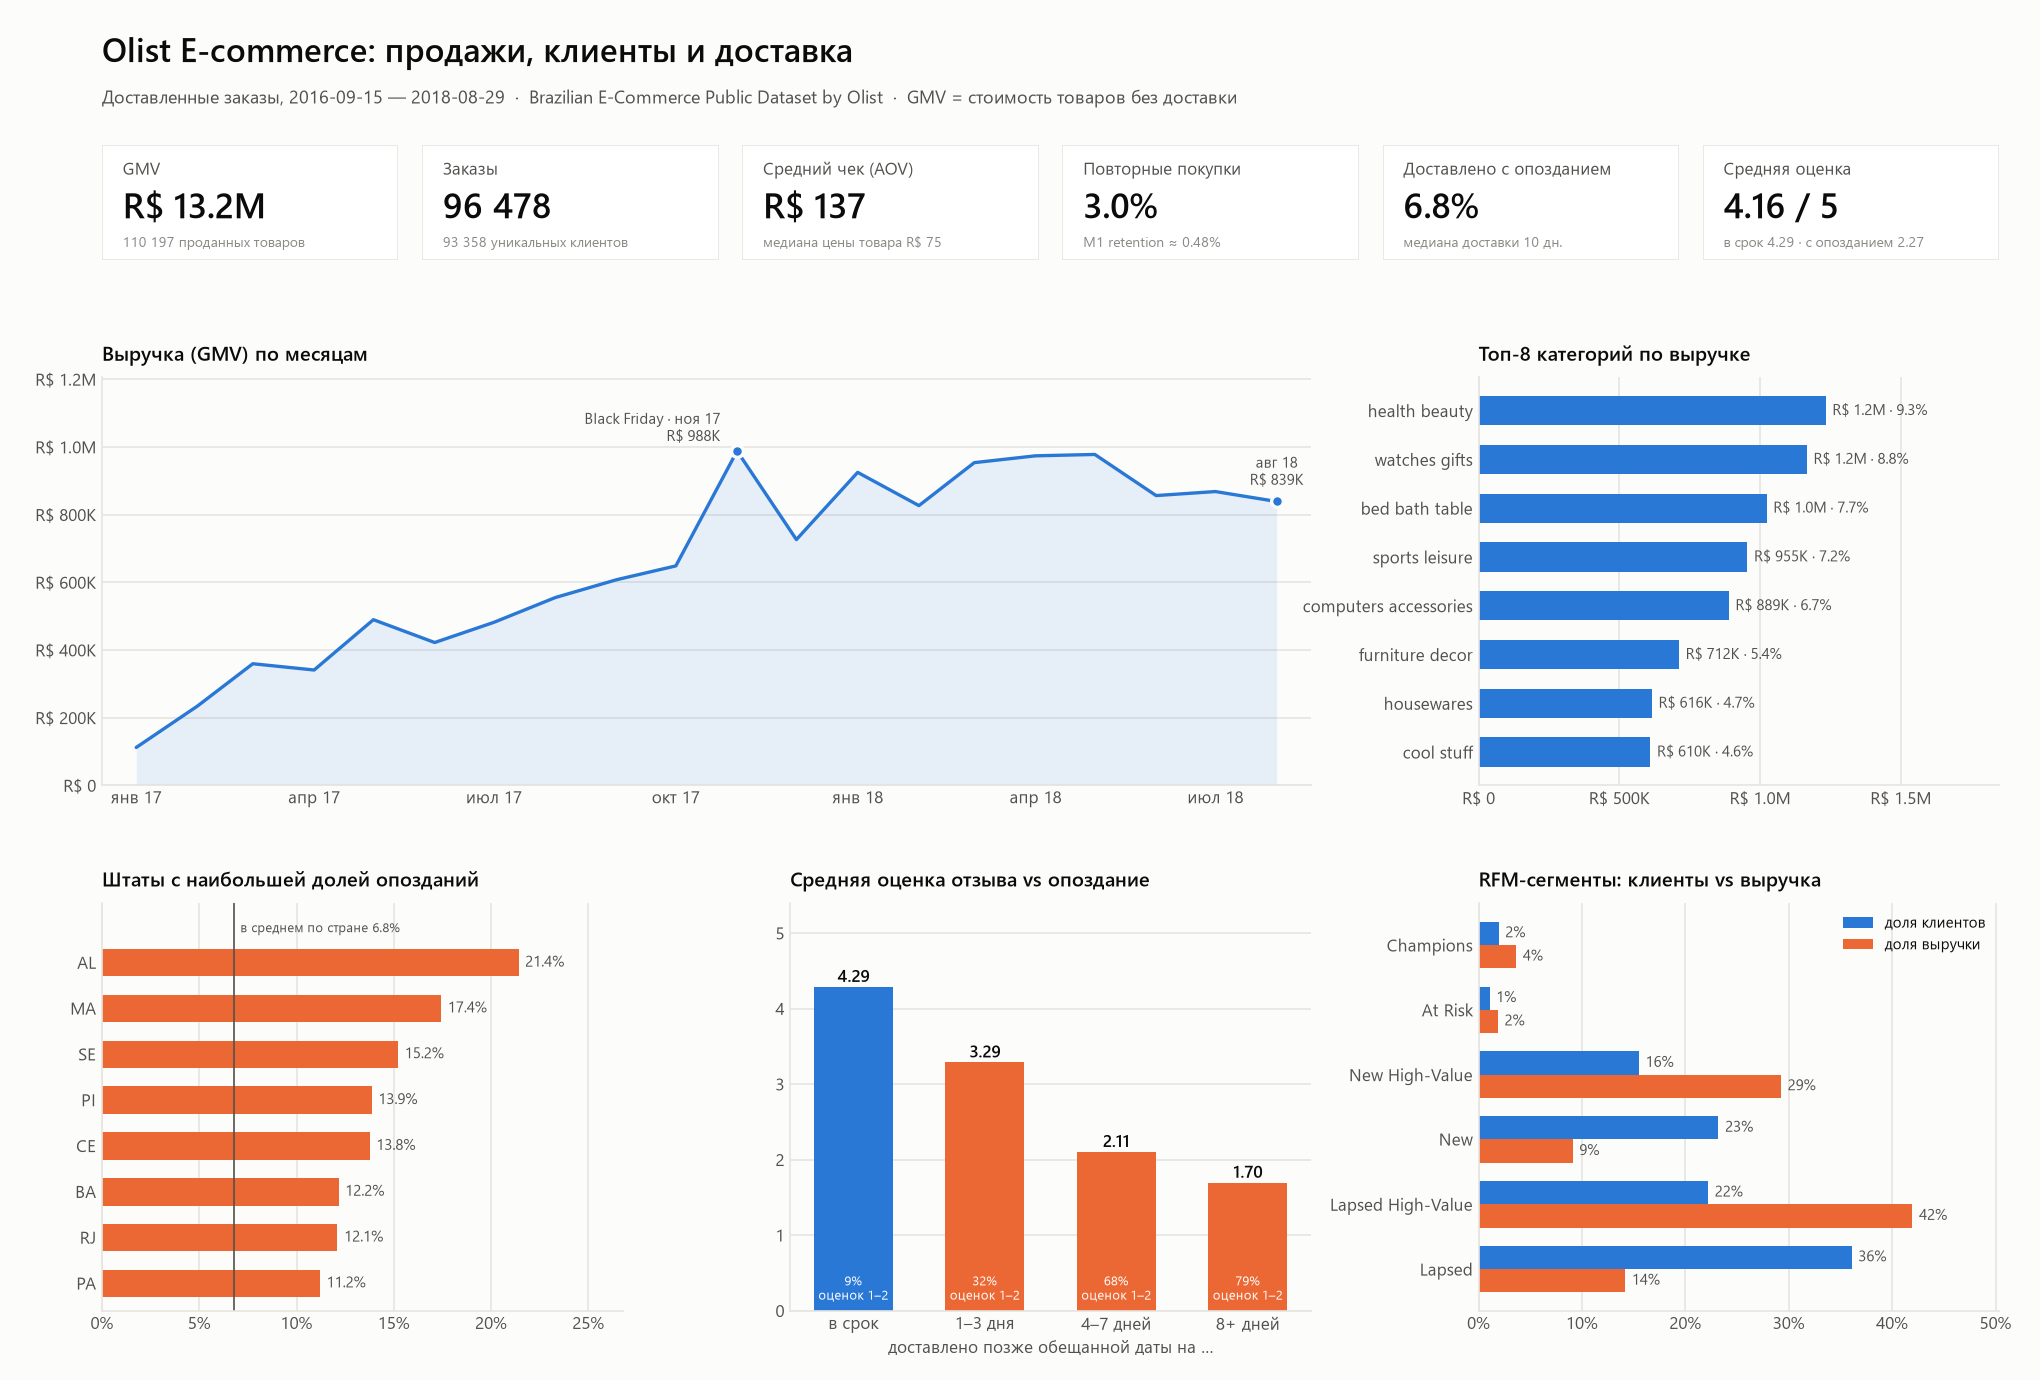

In [4]:
display(Image(FIG / "dashboard.png"))

## 3. Динамика продаж
Осень 2016 года — тестовый запуск (в ноябре 2016 доставленных заказов нет), поэтому график начинается с января 2017. Пик приходится на ноябрь 2017 (Black Friday). В 2018 году рост останавливается на уровне около R$ 0,85–1,0 млн в месяц.

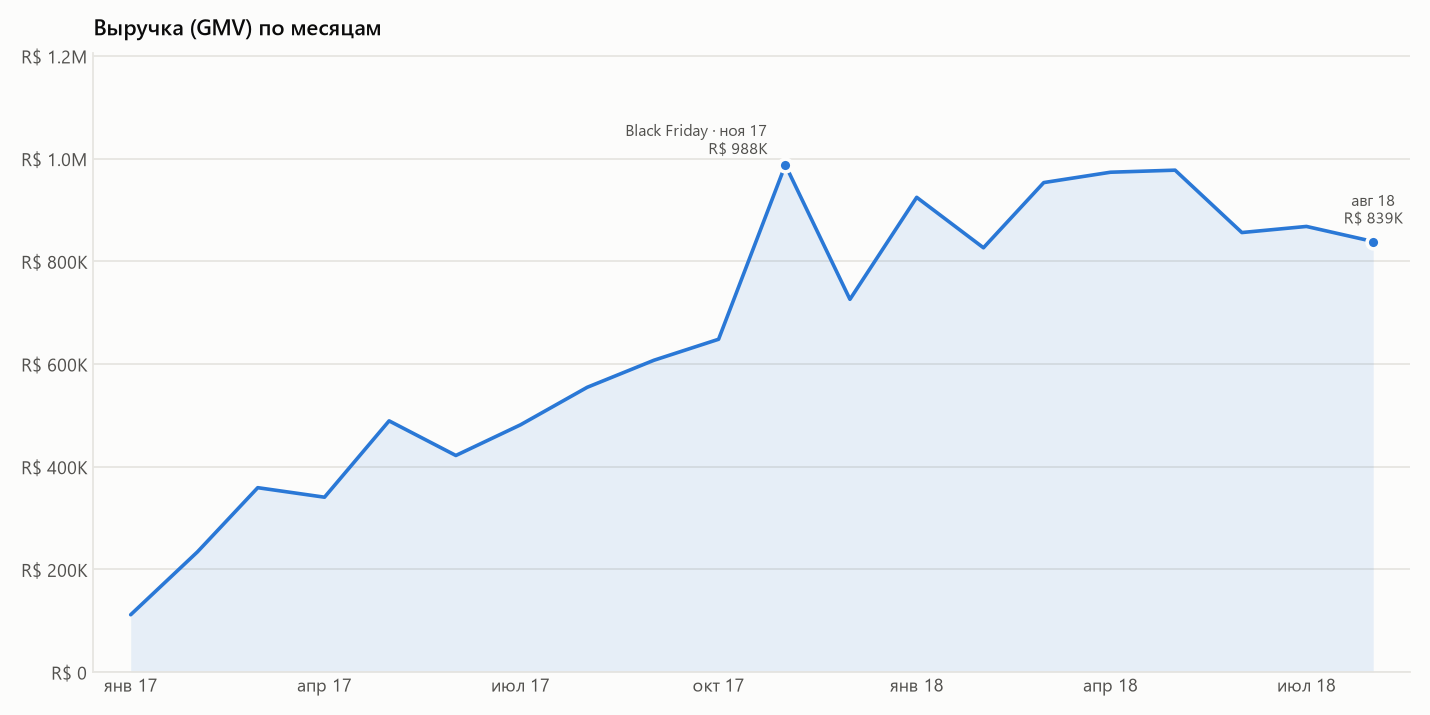

,month,revenue,orders,customers,aov,revenue_mom_pct
12,2017-09,"607,399.67",4150,4083,146.36,9.50
13,2017-10,"648,247.65",4478,4417,144.76,6.70
14,2017-11,"987,765.37",7289,7183,135.51,52.40
15,2017-12,"726,033.19",5513,5450,131.69,-26.50
16,2018-01,"924,645.00",7069,6974,130.80,27.40
17,2018-02,"826,437.13",6555,6400,126.08,-10.60
18,2018-03,"953,356.25",7003,6914,136.14,15.40
19,2018-04,"973,534.09",6798,6744,143.21,2.10
20,2018-05,"977,544.69",6749,6693,144.84,0.40
21,2018-06,"856,077.86",6099,6061,140.36,-12.40


In [5]:
display(Image(FIG / "monthly_gmv.png"))
r["monthly"].tail(12)

## 4. Категории и регионы

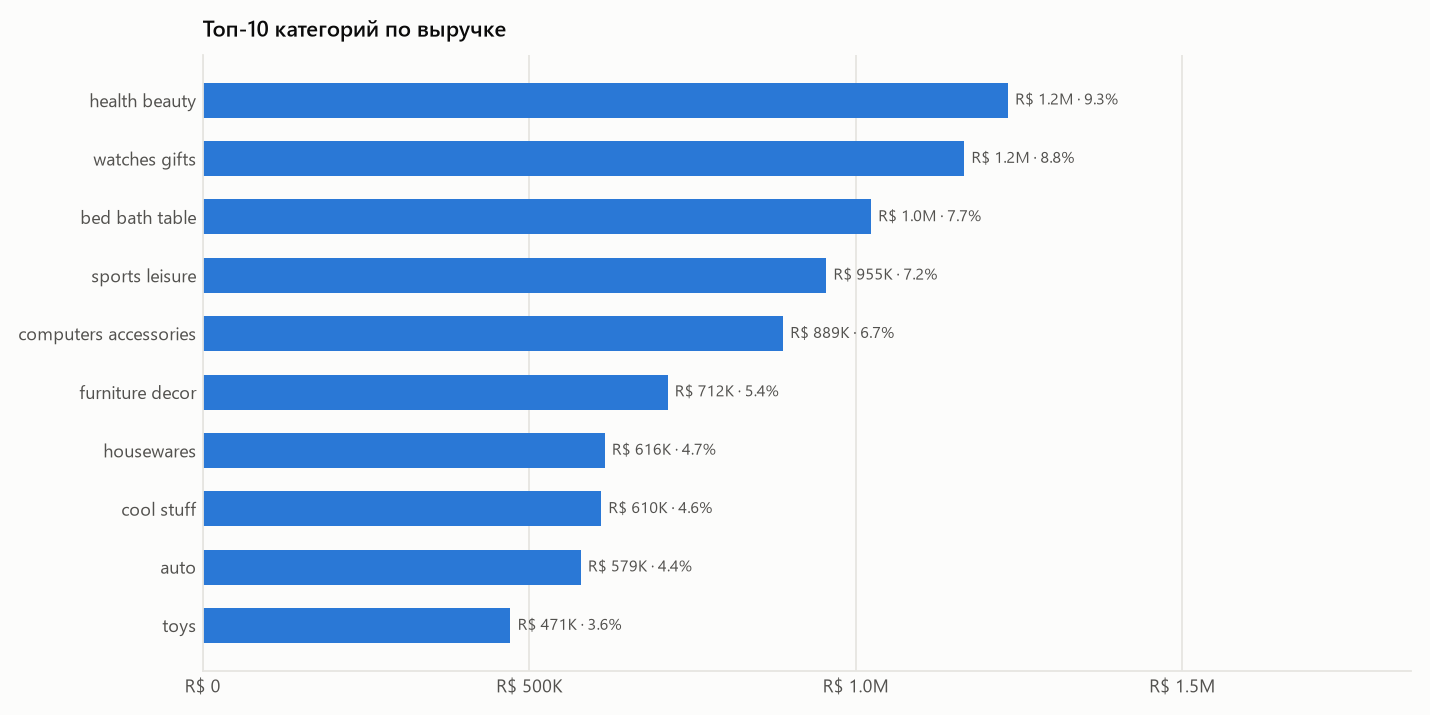

,category,revenue,orders,items,aov,revenue_share_pct,cumulative_share_pct,revenue_rank
0,health_beauty,"1,233,131.72",8647,9465,142.61,9.33,9.33,1
1,watches_gifts,"1,166,176.98",5495,5859,212.23,8.82,18.15,2
2,bed_bath_table,"1,023,434.76",9272,10953,110.38,7.74,25.89,3
3,sports_leisure,"954,852.55",7530,8431,126.81,7.22,33.11,4
4,computers_accessories,"888,724.61",6530,7644,136.10,6.72,39.83,5
5,furniture_decor,"711,927.69",6307,8160,112.88,5.38,45.22,6
6,housewares,"615,628.69",5743,6795,107.20,4.66,49.87,7
7,cool_stuff,"610,204.10",3559,3718,171.45,4.62,54.49,8
8,auto,"578,966.65",3810,4140,151.96,4.38,58.87,9
9,toys,"471,286.48",3804,4030,123.89,3.56,62.43,10


In [6]:
display(Image(FIG / "top_categories.png"))
r["cat"].head(10)

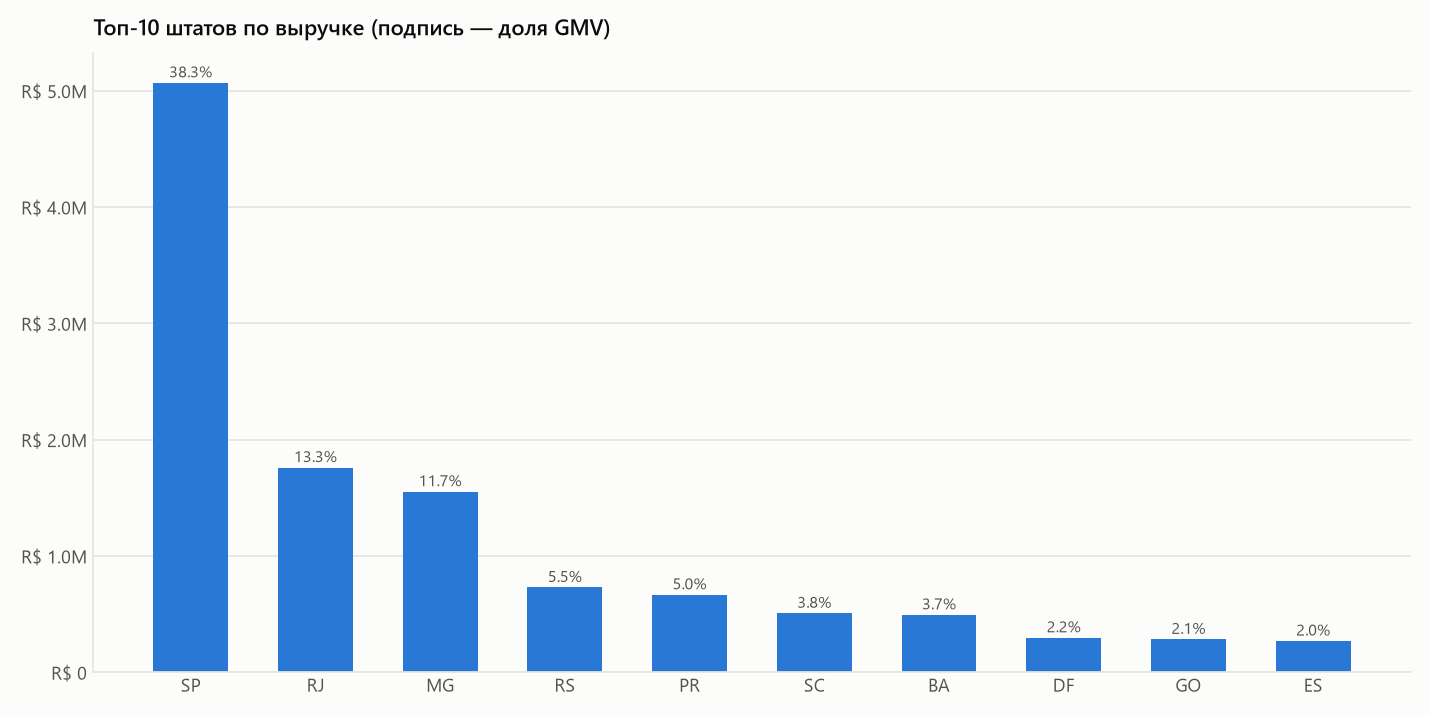

,customer_state,revenue,orders,customers,aov,revenue_share_pct
0,SP,"5,067,633.16",40501,39156,125.12,38.33
1,RJ,"1,759,651.13",12350,11917,142.48,13.31
2,MG,"1,552,481.83",11354,11001,136.73,11.74
3,RS,"728,897.47",5345,5168,136.37,5.51
4,PR,"666,063.51",4923,4769,135.30,5.04
5,SC,"507,012.13",3546,3449,142.98,3.83
6,BA,"493,584.14",3256,3158,151.59,3.73
7,DF,"296,498.41",2080,2019,142.55,2.24
8,GO,"282,836.70",1957,1895,144.53,2.14
9,ES,"268,643.45",1995,1928,134.66,2.03


In [7]:
display(Image(FIG / "top_states.png"))
r["region"].head(10)

## 5. Доставка и отзывы
Опоздание — главный фактор негативных отзывов: при задержке больше недели почти 80% оценок равны 1–2.

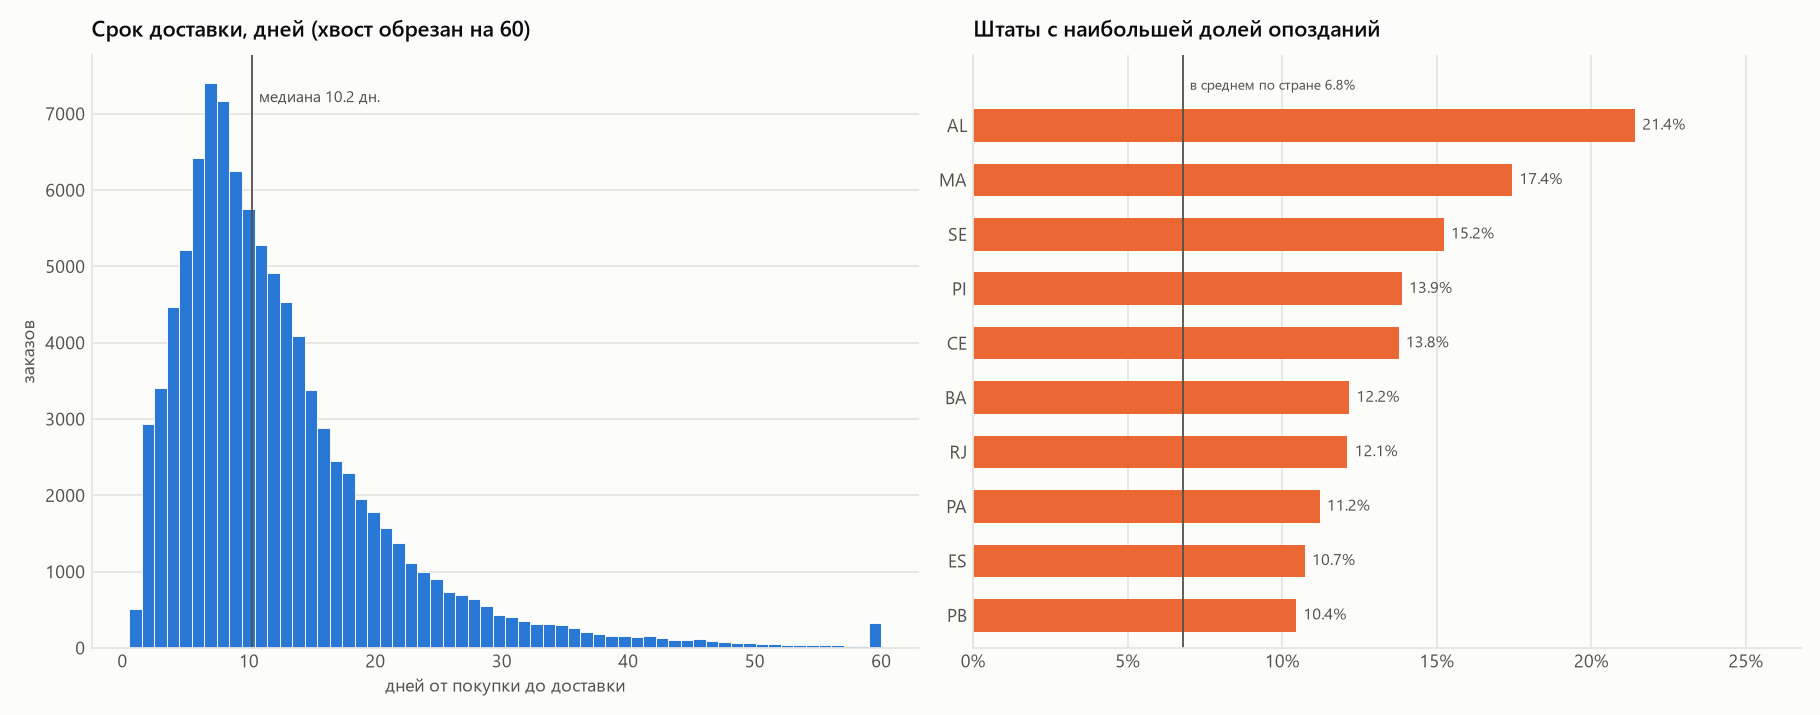

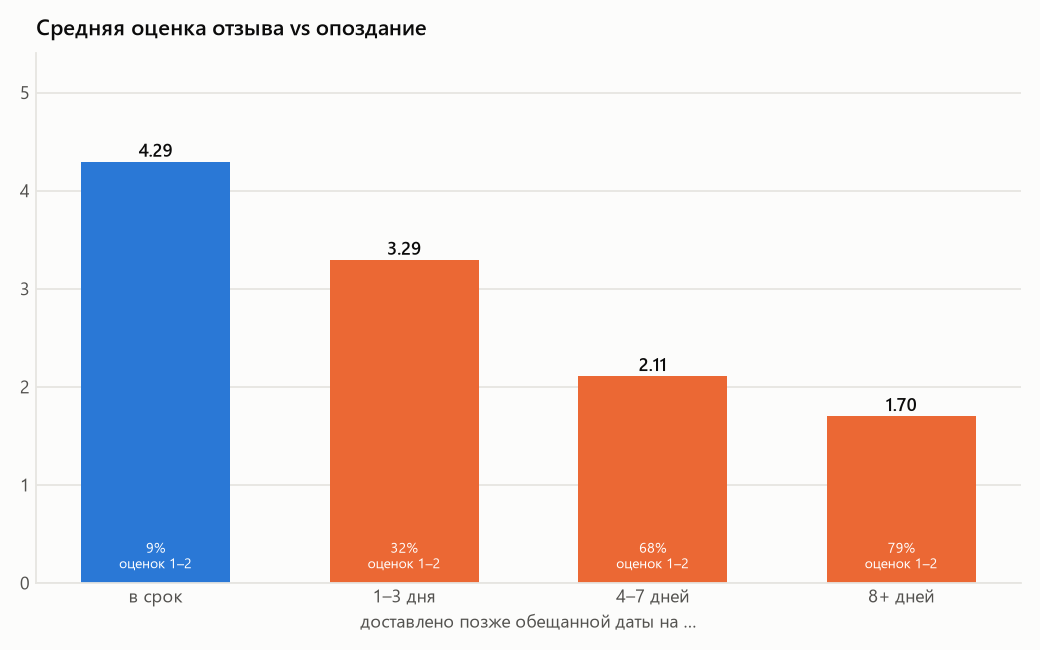

,delay_bucket,orders,avg_review_score,negative_review_pct
0,on_time,89443,4.29,9.23
1,late_1_3d,1852,3.29,32.18
2,late_4_7d,1748,2.11,67.56
3,late_8d_plus,2781,1.70,79.18


In [8]:
display(Image(FIG / "delivery_analysis.png"))
display(Image(FIG / "review_by_delay.png"))
r["review_by_delay"]

In [9]:
r["late_by_state"].head(10)

,customer_state,orders,avg_delivery_days,late_rate_pct
0,AL,397,24.54,21.41
1,MA,717,21.57,17.43
2,SE,335,21.52,15.22
3,PI,476,19.46,13.87
4,CE,1279,21.27,13.76
5,BA,3256,19.34,12.16
6,RJ,12350,15.31,12.11
7,PA,946,23.77,11.21
8,ES,1995,15.79,10.73
9,PB,517,20.43,10.44


## 6. Выбросы в ценах
Выбросы по IQR — это не ошибки в данных, а дорогие товары: около 7% позиций дают около 35% выручки.

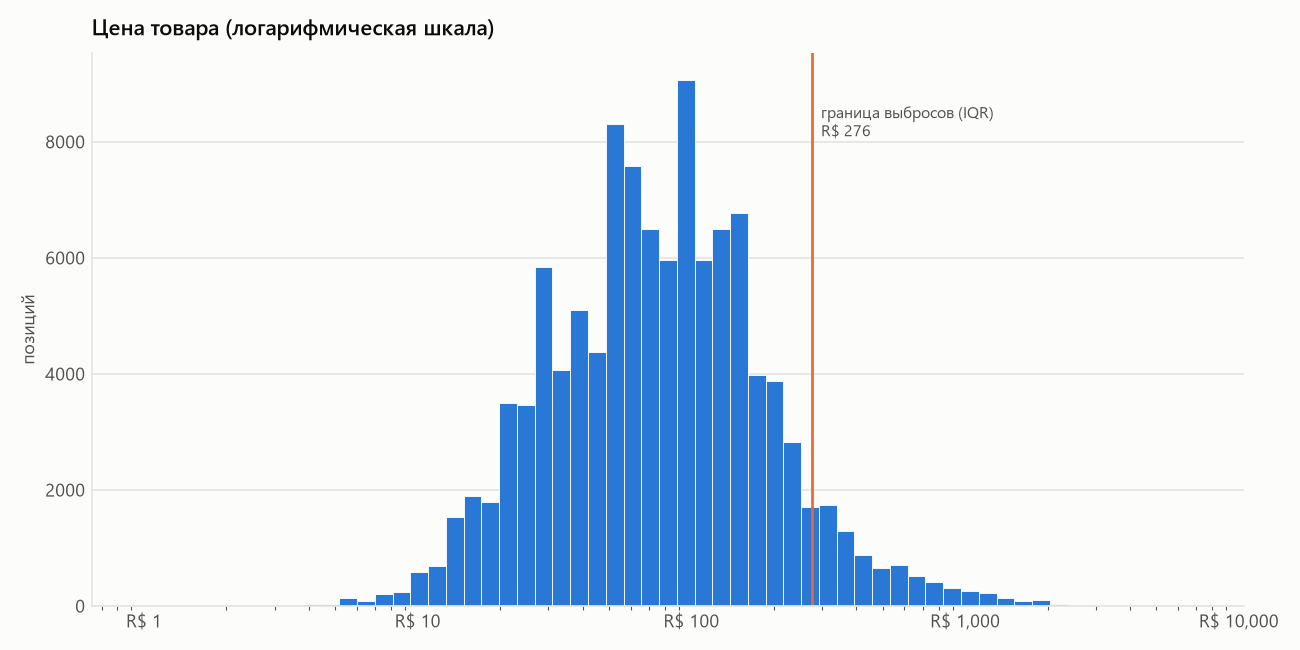

,value
price_median,74.90
price_mean,119.98
price_p95,349.00
price_p99,887.08
iqr_upper,275.57
outlier_items,"8,162.00"
outlier_pct,7.41
outlier_revenue_share_pct,35.31


In [10]:
display(Image(FIG / "price_outliers.png"))
pd.Series(r["price_stats"], name="value").to_frame()

## 7. RFM-сегментация

У 97% клиентов ровно один заказ. Квинтили по frequency здесь не работают: одинаковые разовые покупатели попадали бы в разные группы случайно. Поэтому:
- **F** — фактическое число заказов: повторные клиенты делятся по давности на *Champions* (R 3–5) и *At Risk* (R 1–2);
- разовые клиенты делятся по **R** (4–5 — купили недавно) и **M** (4–5 — верхние 40% по сумме): *New High-Value*, *New*, *Lapsed High-Value*, *Lapsed*.

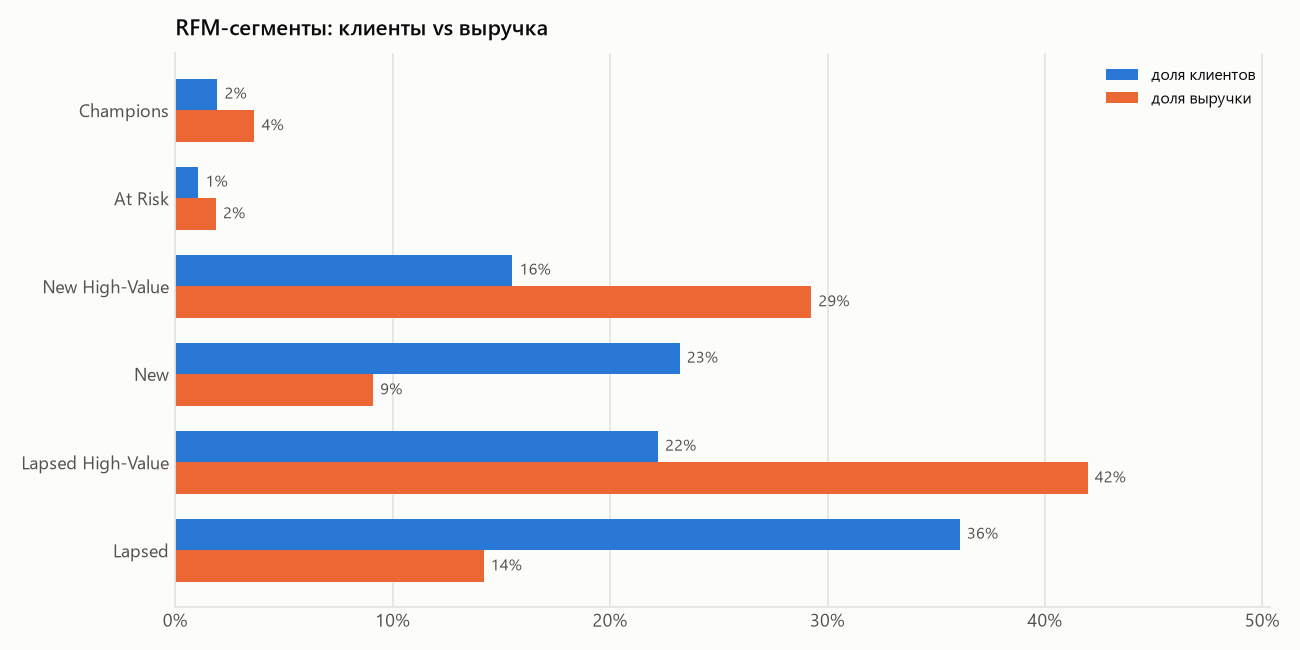

,segment,customers,revenue,avg_monetary,avg_frequency,avg_recency_days,customer_share_pct,revenue_share_pct
0,Champions,1809,"481,352.09",266.09,2.13,132.22,1.94,3.64
1,At Risk,992,"247,056.66",249.05,2.08,382.37,1.06,1.87
2,New High-Value,14479,"3,867,446.58",267.11,1.00,92.21,15.51,29.25
3,New,21662,"1,202,693.89",55.52,1.00,90.12,23.20,9.10
4,Lapsed High-Value,20727,"5,548,034.47",267.67,1.00,336.68,22.20,41.96
5,Lapsed,33689,"1,874,914.42",55.65,1.00,337.79,36.09,14.18


In [11]:
display(Image(FIG / "rfm_segments.png"))
r["seg"]

## 8. Когортный retention
Возврат в следующем месяце составляет около 0,5% когорты. Olist — маркетплейс разовых покупок, и основной рычаг роста здесь — привлечение и конверсия, а не удержание.

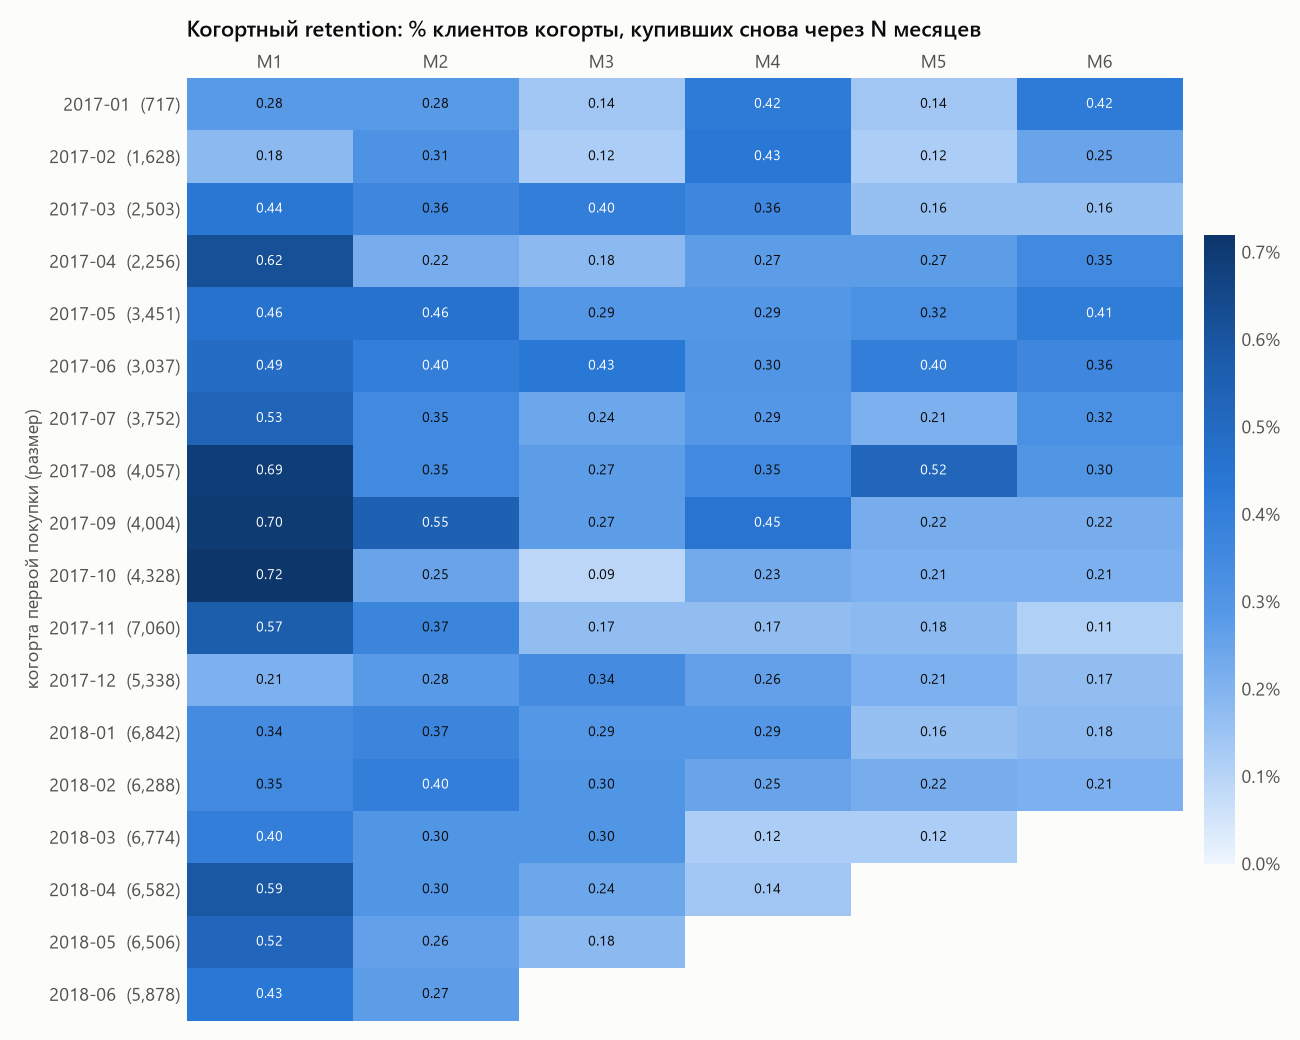

months_since_first_order,1,2,3,4,5,6
2017-01,0.28,0.28,0.14,0.42,0.14,0.42
2017-02,0.18,0.31,0.12,0.43,0.12,0.25
2017-03,0.44,0.36,0.40,0.36,0.16,0.16
2017-04,0.62,0.22,0.18,0.27,0.27,0.35
2017-05,0.46,0.46,0.29,0.29,0.32,0.41
2017-06,0.49,0.40,0.43,0.30,0.40,0.36
2017-07,0.53,0.35,0.24,0.29,0.21,0.32
2017-08,0.69,0.35,0.27,0.35,0.52,0.30
2017-09,0.70,0.55,0.27,0.45,0.22,0.22
2017-10,0.72,0.25,0.09,0.23,0.21,0.21


In [12]:
display(Image(FIG / "retention_heatmap.png"))
r["retention_pivot"]

## 9. Выводы
Полный список выводов — в `outputs/key_findings.md`, рекомендации — в README.

In [13]:
print((ROOT / "outputs" / "key_findings.md").read_text(encoding="utf-8"))

# Key findings

_Файл генерируется `scripts/run_analysis.py` — не редактировать вручную._

## KPI (доставленные заказы)
- Период: 2016-09-15 → 2018-08-29
- GMV: R$ 13,221,498.11 (с доставкой R$ 15,419,773.75)
- Заказы: 96,478 · клиенты: 93,358 · AOV: R$ 137.04
- Repeat purchase rate: 3.0% · M1 retention (взвешенно по когортам 2017-01…2018-06): 0.48%
- Доставка: в среднем 12.56 дн., медиана 10.22 дн.; с опозданием 6.77%
- Средняя оценка отзыва: 4.16

## Продажи
- Пик — 2017-11 (Black Friday): R$ 987,765.
- Топ-5 категорий дают 39.8% выручки; лидер — **health_beauty** (9.3%).
- Среди 15 самых массовых категорий минимальный AOV у **electronics** (R$ 61.60, 2,517 заказов), максимальный — у **watches_gifts** (R$ 212.23).
- Штат SP даёт 38.3% выручки.

## Доставка и отзывы
- Штаты с наибольшей долей опозданий: AL (21.4%), MA (17.4%), SE (15.2%).
- Оценка: в срок 4.29, опоздание 1–3 дня 3.29, 8+ дней 1.70; доля оценок 1–2: 9% → 79%.
- IQR-выбросы по сроку доставки: 5.1% заказов.

## Клиенты
-